In [39]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import random
import torch
import torch.nn as nn
from torch.utils.data import Dataset ,DataLoader
import torch.nn.functional as F
from torch.optim import Adam
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder , MultiLabelBinarizer
from dataclasses import dataclass, field
from torch.optim.lr_scheduler import ReduceLROnPlateau
import time
from sklearn.metrics import mean_squared_error
from typing import Optional

In [4]:
df = pd.read_csv("/kaggle/input/datasets/f1freak/myrecommendeddatas/movielens_final.csv")

In [5]:
print(df.columns)

Index(['userId', 'movieId', 'rating', 'title', 'genres', 'gender', 'age',
       'occupation'],
      dtype='object')


In [6]:


class GetAllEstimation:

    def __init__(self, df):
        self.df = df


    def basic_info(self):
        print("Shape:", self.df.shape)
        print("\nColumns:", self.df.columns)
        print("\nUnique values:\n", self.df.nunique())
        print("\nInfo:")
        print(self.df.info())
    def findingNull(self):
      print("Null Values in DataSet")
      print(df.isnull().sum())


    def rating_distribution(self):
        plt.figure(figsize=(6,4))
        sns.countplot(x="rating", data=self.df)
        plt.title("Rating Distribution")
        plt.show()


    def gender_vs_rating(self):
        plt.figure(figsize=(6,4))
        sns.countplot(x="rating", hue="gender", data=self.df)
        plt.title("Rating vs Gender")
        plt.show()


    def age_vs_rating(self):
        plt.figure(figsize=(8,4))
        sns.countplot(x="age", hue="rating", data=self.df)
        plt.title("Age vs Rating")
        plt.xticks(rotation=45)
        plt.show()


    def occupation_vs_rating(self):
        plt.figure(figsize=(12,5))
        sns.countplot(x="occupation", hue="rating", data=self.df)
        plt.title("Occupation vs Rating")
        plt.xticks(rotation=90)
        plt.show()


    def top_movies(self):
        top = self.df["title"].value_counts().head(10)

        plt.figure(figsize=(10,5))
        sns.barplot(x=top.values, y=top.index)
        plt.title("Top 10 Movies")
        plt.show()


    def genre_rating(self):
        genre_avg = self.df.groupby("genres")["rating"].mean().sort_values(ascending=False).head(10)

        plt.figure(figsize=(10,5))
        sns.barplot(x=genre_avg.values, y=genre_avg.index)
        plt.title("Top Genres by Avg Rating")
        plt.show()


    def gender_5star(self):
        five_star = self.df[self.df["rating"] == 5]

        plt.figure(figsize=(5,4))
        sns.countplot(x="gender", data=five_star)
        plt.title("5-Star Ratings by Gender")
        plt.show()


    def correlation_heatmap(self):
        pivot = self.df.pivot_table(
            index="gender",
            columns="rating",
            values="userId",
            aggfunc="count"
        )

        sns.heatmap(pivot, annot=True, fmt=".0f")
        plt.title("Gender vs Rating Heatmap")
        plt.show()
    def userMaxContributionRating(self):
      user_rating_freq = self.df.groupby(["userId", "rating"]).size().reset_index(name="count")
      print(user_rating_freq)




*   SomeQuestion how many frequency of each user in dataset
*   Only 3000 around movies what is wrong



Shape: (1000209, 8)

Columns: Index(['userId', 'movieId', 'rating', 'title', 'genres', 'gender', 'age',
       'occupation'],
      dtype='object')

Unique values:
 userId        6040
movieId       3706
rating           5
title         3706
genres         301
gender           2
age              7
occupation      21
dtype: int64

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000209 entries, 0 to 1000208
Data columns (total 8 columns):
 #   Column      Non-Null Count    Dtype 
---  ------      --------------    ----- 
 0   userId      1000209 non-null  int64 
 1   movieId     1000209 non-null  int64 
 2   rating      1000209 non-null  int64 
 3   title       1000209 non-null  object
 4   genres      1000209 non-null  object
 5   gender      1000209 non-null  object
 6   age         1000209 non-null  int64 
 7   occupation  1000209 non-null  int64 
dtypes: int64(5), object(3)
memory usage: 61.0+ MB
None
Null Values in DataSet
userId        0
movieId       0
rating        0
titl

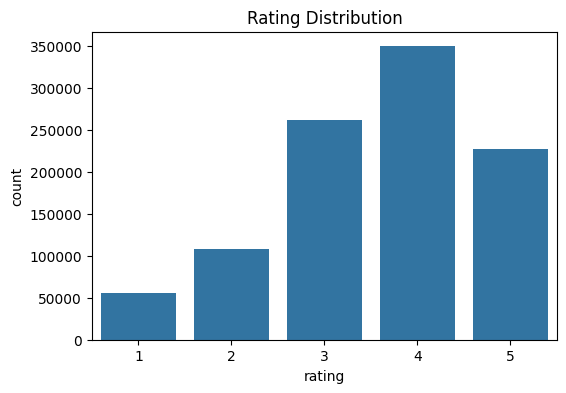

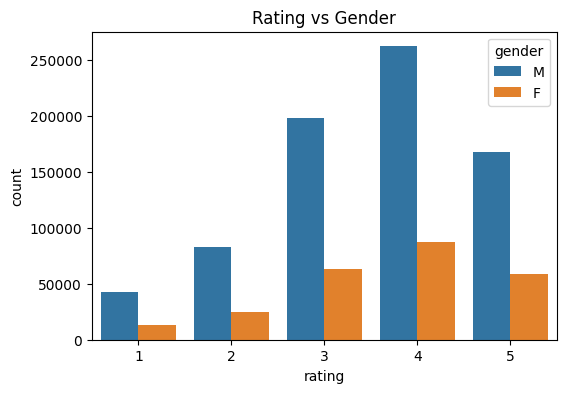

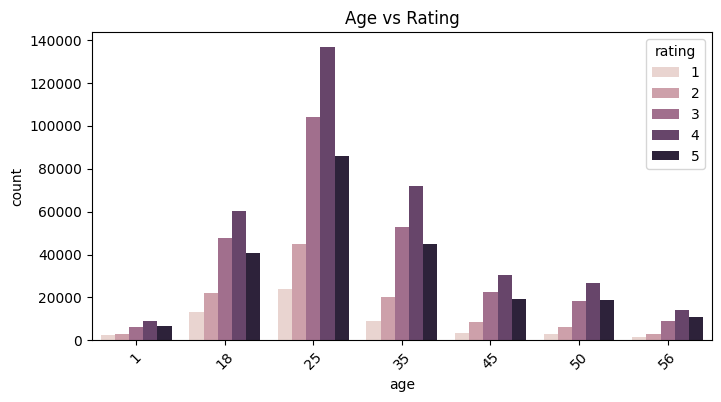

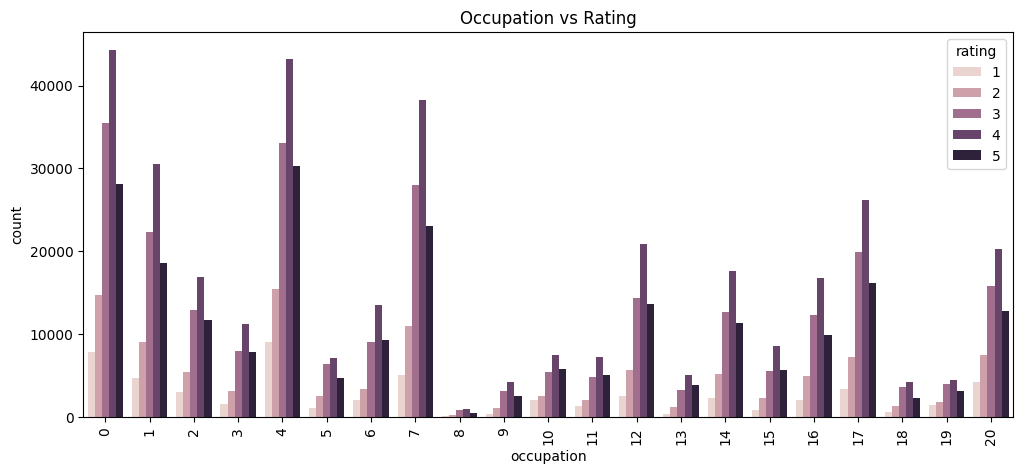

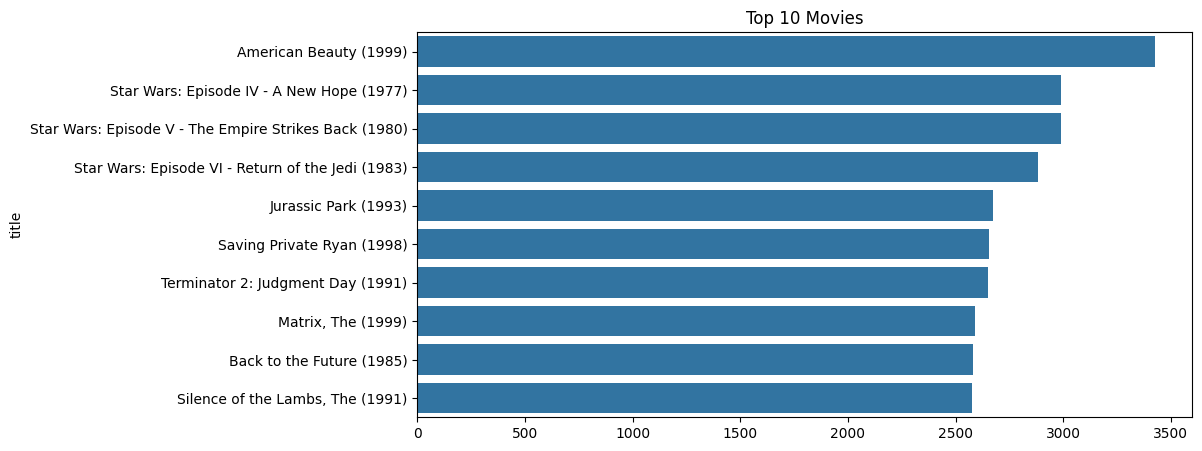

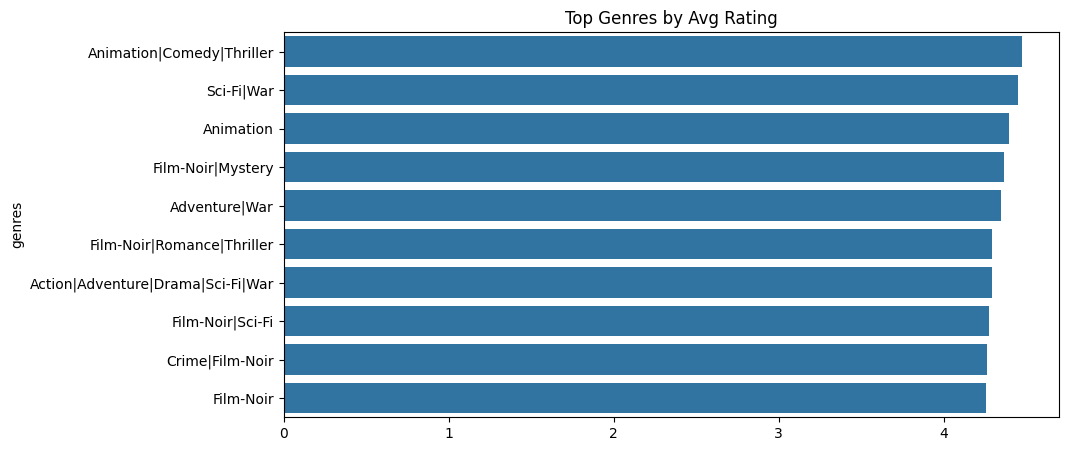

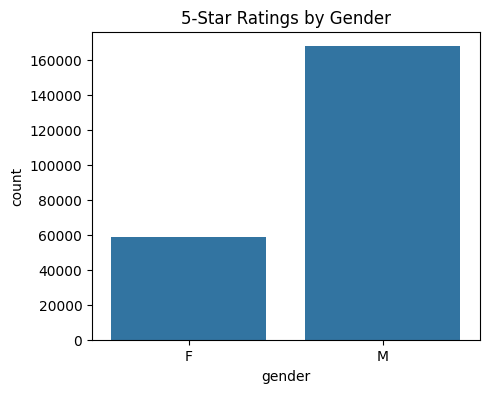

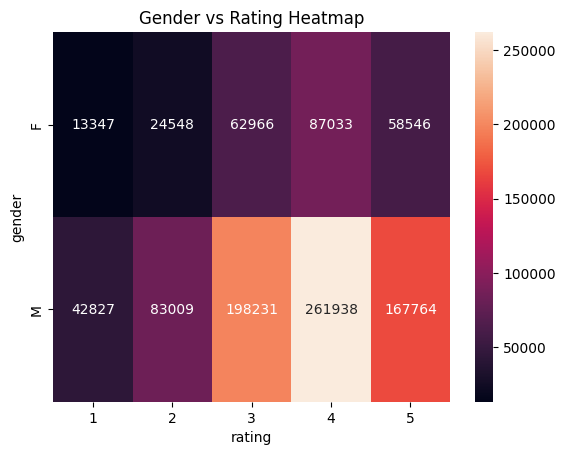

       userId  rating  count
0           1       3      8
1           1       4     27
2           1       5     18
3           2       1      2
4           2       2     11
...       ...     ...    ...
28365    6040       1     27
28366    6040       2     38
28367    6040       3     63
28368    6040       4    137
28369    6040       5     76

[28370 rows x 3 columns]


In [7]:
eda = GetAllEstimation(df)

eda.basic_info()
eda.findingNull()
eda.rating_distribution()
eda.gender_vs_rating()
eda.age_vs_rating()
eda.occupation_vs_rating()
eda.top_movies()
eda.genre_rating()
eda.gender_5star()
eda.correlation_heatmap()
eda.userMaxContributionRating()

In [8]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

In [9]:
DEVICE = torch.device("cuda"  if torch.cuda.is_available() else "cpu")
print(f'Device Used here {DEVICE}')

Device Used here cuda


In [10]:
class DataPreprocessor:
    def __init__(self):
        self.user_enc = LabelEncoder()
        self.movie_enc = LabelEncoder()
        self.gender_enc = LabelEncoder()
        self.age_enc = LabelEncoder()

        self.mlb = MultiLabelBinarizer()
        self.fitted = False
    @staticmethod
    def _split_genres(series : pd.Series) -> list[list[str]]:
      return series.fillna("Unknown").str.split("|").tolist()
    def fit(self, df):
        self.user_enc.fit(df["userId"])
        self.movie_enc.fit(df["movieId"])
        self.gender_enc.fit(df["gender"])
        self.age_enc.fit(df["age"])

        self.mlb.fit(self._split_genres(df["genres"]))
        self.fitted = True
        return self

    def transform(self, df):
        assert self.fitted, "Call fit before transform"

        df = df.copy()

        def safe_transform(enc, col):
            known = set(enc.classes_)
            return np.array([
                enc.transform([v])[0] if v in known else 0
                for v in df[col]
            ])

        df["userId"] = self.user_enc.transform(df["userId"])
        df["movieId"] = self.movie_enc.transform(df["movieId"])
        df["gender"] = self.gender_enc.transform( df["gender"])
        df["age"] = self.age_enc.transform(df["age"])
        df["occupation"] = df['occupation'].astype(int)
        genre_matrix = self.mlb.transform(self._split_genres(df["genres"])) # will give me 2 dimesional list here
        df["genre_vec"] = list(genre_matrix.astype(np.float32))

        return df

    @property
    def num_users(self):
        return len(self.user_enc.classes_)

    @property
    def num_movies(self):
        return len(self.movie_enc.classes_)

    @property
    def num_ages(self):
        return len(self.age_enc.classes_)

    @property
    def num_occupations(self):
        return len(self.occ_enc.classes_) # this property  is faulted i did not apply label Encoder on this so no use of this
    @property
    def genre_labels(self) : return list(self.mlb.classes_)

    @property
    def num_genres(self) : return len(self.mlb.classes_)

In [11]:
df = df.dropna()
df = df[df["rating"].between(1, 5)]



In [12]:
preprocessor  =DataPreprocessor()
preprocessor.fit(df)

df_processed = preprocessor.transform(df)

In [13]:
print(preprocessor.genre_labels)

['Action', 'Adventure', 'Animation', "Children's", 'Comedy', 'Crime', 'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']


In [14]:
train_val_df , test_df = train_test_split(df_processed, test_size = 0.3 , random_state = SEED)
train_df , val_df = train_test_split(train_val_df, test_size = 0.3, random_state = SEED)

In [15]:


class MovieDataset(Dataset):
    def __init__(self, df):
        self.users = torch.tensor(df["userId"].values, dtype=torch.long)
        self.movies = torch.tensor(df["movieId"].values, dtype=torch.long)
        self.gender = torch.tensor(df["gender"].values, dtype=torch.long)
        self.occupation = torch.tensor(df["occupation"].values, dtype=torch.long)
        self.age = torch.tensor(df["age"].values, dtype=torch.long)
        self.genres = torch.tensor(np.stack(df['genre_vec'].values) ,dtype = torch.float32)
        self.ratings = torch.tensor(
            df["rating"].values,
            dtype=torch.float32
        )
    def __len__(self):
        return len(self.ratings)
    def __getitem__(self, idx):
        return (
            self.users[idx],
            self.movies[idx],
            self.gender[idx],
            self.occupation[idx],
            self.age[idx],
            self.genres[idx],
            self.ratings[idx],
        )

In [16]:
def makeLoader(df:pd.DataFrame , shuffle : bool , batch_size :int ) -> DataLoader:
    return DataLoader(
        MovieDataset(df),
        batch_size = batch_size,
        shuffle = shuffle ,
        num_workers = 0,
        pin_memory=  (DEVICE.type == "cuda"),
    )

In [17]:
train_loader = makeLoader(train_df, True, 200)
test_loader = makeLoader(test_df, False, 200)
val_loader = makeLoader(val_df,False , 200)

In [18]:
users, movies, genders, occs, ages, genres, ratings = next(iter(train_loader))
print(f"users:   {users.shape}   dtype={users.dtype}")
print(f"movies:  {movies.shape}  dtype={movies.dtype}")
print(f"genres:  {genres.shape}  dtype={genres.dtype}  ← multi-hot vector")
print(f"ratings: {ratings.shape} dtype={ratings.dtype} ← y (target)")

users:   torch.Size([200])   dtype=torch.int64
movies:  torch.Size([200])  dtype=torch.int64
genres:  torch.Size([200, 18])  dtype=torch.float32  ← multi-hot vector
ratings: torch.Size([200]) dtype=torch.float32 ← y (target)


In [19]:
class NCFRecommender(nn.Module):
  def __init__(
      self,
      num_users: int ,
      num_movies :int,
      num_genders : int,
      num_ages : int ,
      num_occupations :int ,
      num_genres :int ,
      user_emb_dim :int = 64 ,
      movie_emb_dim :int  = 64 ,
      genre_proj_dim :int = 32,
      hidden_dims : list = None,
      dropout : float = 0.3 ,
    ):
    super().__init__()
    hidden_dims = hidden_dims or [512, 256 , 128 , 64 , 32 ,16 , 8 ]
    self.user_emb = nn.Embedding(num_users + 1, user_emb_dim , padding_idx =0)
    self.movie_emb = nn.Embedding(num_movies + 1 , movie_emb_dim, padding_idx =0)
    self.gender_emb = nn.Embedding(num_genders + 1 , 8)
    self.age_emb = nn.Embedding(num_ages + 1 , 8)
    self.occ_emb  = nn.Embedding(num_occupations + 1 , 16)
    self.genre_proj = nn.Sequential(
        nn.Linear(num_genres, genre_proj_dim),
        nn.ReLU(),
    )
    in_dim = user_emb_dim + movie_emb_dim + 8 + 8 + 16 + genre_proj_dim
    layers  = []
    for out_dim in hidden_dims:
      layers += [
          nn.Linear(in_dim , out_dim),
          nn.BatchNorm1d(out_dim),
          nn.SiLU(),
          nn.Dropout(dropout)
      ]
      in_dim = out_dim
    self.mlp = nn.Sequential(*layers)
    self.output =  nn.Linear(in_dim , 1)
    self.__init__weights()

  def __init__weights(self):
    for m in self.modules():
      if isinstance(m , nn.Linear):
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)
      elif isinstance(m,nn.Embedding):
        nn.init.normal_(m.weight,0,0.01)
  def forward(
      self,
      user_ids : torch.Tensor,
      movie_ids : torch.Tensor,
      gender :torch.Tensor,
      occupation : torch.Tensor,
      age : torch.Tensor,
      genre_vec : torch.Tensor,

      ) -> torch.Tensor:

      x = torch.cat([
          self.user_emb(user_ids),
          self.movie_emb(movie_ids),
          self.gender_emb(gender),
          self.age_emb(age),
          self.occ_emb(occupation),
          self.genre_proj(genre_vec),
      ] , dim = -1)
      x = self.mlp(x)
      return self.output(x).squeeze(1).clamp(1.0, 5.0)







In [20]:
model = NCFRecommender(
    num_users=preprocessor.num_users,
    num_movies=preprocessor.num_movies,
    num_genders=2,
    num_ages=preprocessor.num_ages,
    num_occupations=21,
    num_genres=preprocessor.num_genres,
    user_emb_dim= 12,
    movie_emb_dim= 12,
).to(DEVICE)

In [21]:
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(model)
print(f"\nTrainable parameters: {total_params:,}")

NCFRecommender(
  (user_emb): Embedding(6041, 12, padding_idx=0)
  (movie_emb): Embedding(3707, 12, padding_idx=0)
  (gender_emb): Embedding(3, 8)
  (age_emb): Embedding(8, 8)
  (occ_emb): Embedding(22, 16)
  (genre_proj): Sequential(
    (0): Linear(in_features=18, out_features=32, bias=True)
    (1): ReLU()
  )
  (mlp): Sequential(
    (0): Linear(in_features=88, out_features=512, bias=True)
    (1): BatchNorm1d(512, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): SiLU()
    (3): Dropout(p=0.3, inplace=False)
    (4): Linear(in_features=512, out_features=256, bias=True)
    (5): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): SiLU()
    (7): Dropout(p=0.3, inplace=False)
    (8): Linear(in_features=256, out_features=128, bias=True)
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): SiLU()
    (11): Dropout(p=0.3, inplace=False)
    (12): Linear(in_features=128, out_feat

In [22]:
class EarlyStopping:
  def __init__(self, patience = 5, min_delta = 1e-5):
    self.patience = patience; self.min_delta = min_delta
    self.counter = 0
    self.best_loss = float('inf')
    self.stop = False
  def __call__(self,val_loss):
    if val_loss < self.best_loss - self.min_delta:
      self.best_loss = val_loss ;self.counter =0
    else:
      self.counter += 1
      if self.counter >= self.patience : self.stop = True
    return self.stop



In [23]:
def run_epoch(model, loader,criterion , optimizer = None):
  is_train = optimizer is not None
  model.train() if is_train else model.eval()
  total_loss = n = 0
  count = 0
  ctx = torch.enable_grad() if is_train else torch.no_grad()
  with ctx:
    for users , movies, genders ,occs, ages, genres, ratings in loader:
      users, movies, genders = users.to(DEVICE), movies.to(DEVICE), genders.to(DEVICE)
      occs, ages, genres     = occs.to(DEVICE), ages.to(DEVICE), genres.to(DEVICE)
      ratings                = ratings.to(DEVICE)

      preds = model(users, movies, genders, occs, ages, genres)
      loss  = criterion(preds, ratings)
      if is_train:
        optimizer.zero_grad();loss.backward()
        nn.utils.clip_grad_norm_(model.parameters() ,1)
        optimizer.step()
      total_loss += loss.item() * len(ratings) ; n += len(ratings);count+= 1

  return total_loss / n




In [24]:
criterion = nn.MSELoss()
optimizer = Adam(model.parameters() , lr = 0.01, weight_decay= 1e-5)
scheduler = ReduceLROnPlateau(
    optimizer,
    mode="min",
    patience=5,
    factor=0.5,

)
earlystopper = EarlyStopping(patience  = 5)
train_losses , val_losses = [] ,[]
best_val_loss = float('inf')


In [25]:
print(f'Starting Training.....')
for epoch in range(50):
  start_time = time.perf_counter()
  train_loss = run_epoch(model,train_loader, criterion, optimizer)
  val_loss = run_epoch(model,val_loader,criterion)
  scheduler.step(val_loss)
  train_losses.append(train_loss);val_losses.append(val_loss)
  if val_loss < best_val_loss:
    best_val_loss = val_loss
  print(f"Epoch {epoch}/100 |"
        f"Train MSE : {train_loss :.4f} | "
        f"Val MSE : {val_loss :.4f} | RMSE : {val_loss**0.5:.4f}"
  )
  if earlystopper.__call__(val_loss):
    print(f'Early Stopping at epoch {epoch + 1}');break
  end_time = time.perf_counter()
  print(f'Time taken in {epoch + 1}/{100} in {end_time - start_time} seconds')
print(f"\nBest val RMSE: {best_val_loss**0.5:.4f}")



Starting Training.....
Epoch 0/100 |Train MSE : 1.0792 | Val MSE : 0.8534 | RMSE : 0.9238
Time taken in 1/100 in 30.431999569000027 seconds
Epoch 1/100 |Train MSE : 0.8705 | Val MSE : 0.8308 | RMSE : 0.9115
Time taken in 2/100 in 28.980290821000153 seconds
Epoch 2/100 |Train MSE : 0.8487 | Val MSE : 0.8117 | RMSE : 0.9009
Time taken in 3/100 in 28.828245442000025 seconds
Epoch 3/100 |Train MSE : 0.8336 | Val MSE : 0.8013 | RMSE : 0.8951
Time taken in 4/100 in 28.732303514000023 seconds
Epoch 4/100 |Train MSE : 0.8271 | Val MSE : 0.7987 | RMSE : 0.8937
Time taken in 5/100 in 28.90861698599997 seconds
Epoch 5/100 |Train MSE : 0.8222 | Val MSE : 0.7948 | RMSE : 0.8915
Time taken in 6/100 in 28.70069330499996 seconds
Epoch 6/100 |Train MSE : 0.8200 | Val MSE : 0.7926 | RMSE : 0.8903
Time taken in 7/100 in 28.942946350000057 seconds
Epoch 7/100 |Train MSE : 0.8182 | Val MSE : 0.7933 | RMSE : 0.8907
Time taken in 8/100 in 28.603442295999912 seconds
Epoch 8/100 |Train MSE : 0.8165 | Val MSE :

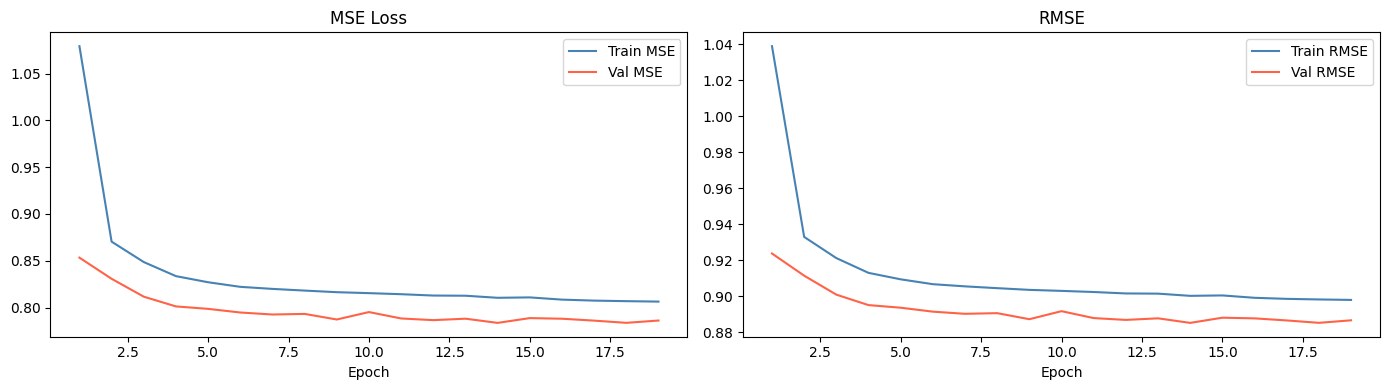

In [27]:
epochs_ran = range(1, len(train_losses) + 1)
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].plot(epochs_ran, train_losses, label="Train MSE", color="steelblue")
axes[0].plot(epochs_ran, val_losses,   label="Val MSE",   color="tomato")
axes[0].set_title("MSE Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend()
axes[1].plot(epochs_ran, [l**0.5 for l in train_losses], label="Train RMSE", color="steelblue")
axes[1].plot(epochs_ran, [l**0.5 for l in val_losses],   label="Val RMSE",   color="tomato")
axes[1].set_title("RMSE"); axes[1].set_xlabel("Epoch"); axes[1].legend()
plt.tight_layout(); plt.savefig("training_curve.png", dpi=150, bbox_inches="tight"); plt.show()

  Test RMSE : 0.8870
  Test MAE  : 0.7040


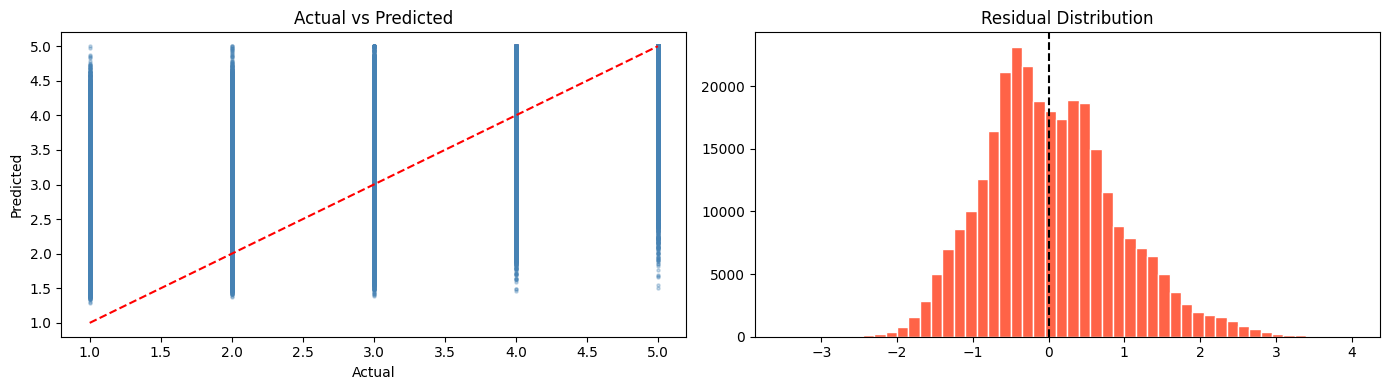

In [31]:


model.eval()
all_preds, all_targets = [], []
with torch.no_grad():
    for users, movies, genders, occs, ages, genres, ratings in test_loader:
        preds = model(
            users.to(DEVICE), movies.to(DEVICE), genders.to(DEVICE),
            occs.to(DEVICE),  ages.to(DEVICE),   genres.to(DEVICE)
        )
        all_preds.extend(preds.cpu().numpy())
        all_targets.extend(ratings.numpy())

all_preds, all_targets = np.array(all_preds), np.array(all_targets)
rmse = np.sqrt(mean_squared_error(all_targets, all_preds))
mae  = np.mean(np.abs(all_targets - all_preds))
print(f"{'='*35}\n  Test RMSE : {rmse:.4f}\n  Test MAE  : {mae:.4f}\n{'='*35}")

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
axes[0].scatter(all_targets, all_preds, alpha=0.3, s=5, color="steelblue")
axes[0].plot([1,5],[1,5],"r--")
axes[0].set_xlabel("Actual"); axes[0].set_ylabel("Predicted"); axes[0].set_title("Actual vs Predicted")
residuals = all_preds - all_targets
axes[1].hist(residuals, bins=50, color="tomato", edgecolor="white")
axes[1].axvline(0, color="black", linestyle="--"); axes[1].set_title("Residual Distribution")
plt.tight_layout(); plt.savefig("evaluation.png", dpi=150, bbox_inches="tight"); plt.show()

In [46]:


class Recommender:
    def __init__(self, model, preprocessor, device, df_raw):
        self.model = model.eval()
        self.device = device
        self.prep = preprocessor

        self._build_movie_index(df_raw)

    def _build_movie_index(self, df_raw):
        movie_meta = df_raw.drop_duplicates("movieId")[["movieId", "title", "genres"]].copy()

        known = set(self.prep.movie_enc.classes_)
        movie_meta = movie_meta[movie_meta["movieId"].isin(known)]

        movie_meta["enc_id"] = self.prep.movie_enc.transform(movie_meta["movieId"])

        genre_lists = movie_meta["genres"].fillna("Unknown").str.split("|").tolist()
        genre_matrix = self.prep.mlb.transform(genre_lists).astype(np.float32)

        self.movie_enc_ids = movie_meta["enc_id"].values
        self.movie_orig_ids = movie_meta["movieId"].values
        self.movie_titles = movie_meta["title"].values
        self.movie_genre_mat = torch.tensor(genre_matrix, dtype=torch.float32)

    @torch.no_grad()
    def recommend(
        self,
        user_id: int,
        gender: str,
        age: int,
        occupation: int,
        top_k: int = 10,
        seen_movies: Optional[list] = None,
    ) -> pd.DataFrame:

        seen = set(seen_movies or [])
        mask = np.array([oid not in seen for oid in self.movie_orig_ids])

        enc_user = self.prep.user_enc.transform([user_id])[0] if user_id in set(self.prep.user_enc.classes_) else 0
        enc_gender = self.prep.gender_enc.transform([gender])[0] if gender in set(self.prep.gender_enc.classes_) else 0
        enc_age = self.prep.age_enc.transform([age])[0] if age in set(self.prep.age_enc.classes_) else 0

        n = mask.sum()
        t = lambda v, dt: torch.tensor([v] * n, dtype=dt).to(self.device)

        preds = self.model(
            t(enc_user, torch.long),
            torch.tensor(self.movie_enc_ids[mask], dtype=torch.long).to(self.device),
            t(enc_gender, torch.long),
            t(occupation, torch.long),
            t(enc_age, torch.long),
            self.movie_genre_mat[mask].to(self.device),
        ).cpu().numpy()

        top_idx = np.argsort(preds)[::-1][:top_k]

        return pd.DataFrame({
            "movieId": self.movie_orig_ids[mask][top_idx],
            "title": self.movie_titles[mask][top_idx],
            "predicted_rating": np.round(preds[top_idx], 3),
        })

In [53]:
recommender = Recommender(model, preprocessor, DEVICE, df)

sample_user = df["userId"].iloc[0]
row = df[df["userId"] == sample_user].iloc[0]
seen = df[df["userId"] == sample_user]["movieId"].tolist()

recs = recommender.recommend(
    user_id=sample_user,
    gender=row["gender"],
    age=row["age"],
    occupation=int(row["occupation"]),
    top_k=10,
    seen_movies=seen
)

print(recs.to_string(index=False))

print(rec.s)

 movieId                                                               title  predicted_rating
     318                                    Shawshank Redemption, The (1994)             4.731
      50                                          Usual Suspects, The (1995)             4.638
     858                                               Godfather, The (1972)             4.563
    2324                          Life Is Beautiful (La Vita è bella) (1997)             4.560
    1223                                             Grand Day Out, A (1992)             4.555
    1198                                      Raiders of the Lost Ark (1981)             4.553
    1148                                          Wrong Trousers, The (1993)             4.533
    2019 Seven Samurai (The Magnificent Seven) (Shichinin no samurai) (1954)             4.525
    2571                                                  Matrix, The (1999)             4.500
    2858                                          